<a href="https://colab.research.google.com/github/Kavishka2401/CustomerChurnPredictionSystem/blob/master/NN_baseline_model_ipynbipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Mount the google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Provide path
data=pd.read_csv('/content/drive/MyDrive/processed_data_NN.csv')

In [5]:
data_baselinemodel=data.copy()

In [6]:
data_baselinemodel.head()

,customerID,tenure,MonthlyCharges,TotalCharges,Churn,TotalCharges_numeric,TotalCharges_log,gender_Male,SeniorCitizen_1,Partner_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0.013889,0.115423,29.85,0,29.85,0.072892,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,5575-GNVDE,0.472222,0.385075,1889.5,0,1889.50,0.749358,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,3668-QPYBK,0.027778,0.354229,108.15,1,108.15,0.280590,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,7795-CFOCW,0.625000,0.239303,1840.75,0,1840.75,0.745063,1,0,0,...,0,0,0,0,1,0,0,0,0,0
4,9237-HQITU,0.027778,0.521891,151.65,1,151.65,0.335724,0,0,0,...,0,0,0,0,0,0,1,0,1,0


In [7]:
# make sure the column names exist
cols_to_drop = ['customerID','Churn', 'TotalCharges', 'TotalCharges_numeric']

# create X by dropping columns
X = data_baselinemodel.drop(columns=cols_to_drop, axis=1)

# create y
y = data_baselinemodel['Churn']

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,        # 20% test set
    stratify=y,            # preserve churn ratio
    random_state=42        # reproducible split
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape: ", X_test.shape, y_test.shape)
print("Train class counts:\n", y_train.value_counts())
print("Test class counts:\n", y_test.value_counts())

Train shape: (5634, 30) (5634,)
Test shape:  (1409, 30) (1409,)
Train class counts:
 Churn
0    4139
1    1495
Name: count, dtype: int64
Test class counts:
 Churn
0    1035
1     374
Name: count, dtype: int64


In [9]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 3738 to 5639
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   tenure                                 5634 non-null   float64
 1   MonthlyCharges                         5634 non-null   float64
 2   TotalCharges_log                       5634 non-null   float64
 3   gender_Male                            5634 non-null   int64  
 4   SeniorCitizen_1                        5634 non-null   int64  
 5   Partner_Yes                            5634 non-null   int64  
 6   Dependents_Yes                         5634 non-null   int64  
 7   PhoneService_Yes                       5634 non-null   int64  
 8   MultipleLines_No phone service         5634 non-null   int64  
 9   MultipleLines_Yes                      5634 non-null   int64  
 10  InternetService_Fiber optic            5634 non-null   int64  
 11  Intern

In [10]:
# First 5 rows of training features
print("X_train sample:")
print(X_train.head())

# First 5 rows of training target
print("\ny_train sample:")
print(y_train.head())

# First 5 rows of test features
print("\nX_test sample:")
print(X_test.head())

# First 5 rows of test target
print("\ny_test sample:")
print(y_test.head())

X_train sample:
        tenure  MonthlyCharges  TotalCharges_log  gender_Male  \
3738  0.486111        0.307960          0.732155            1   
3151  0.208333        0.565672          0.668016            1   
4860  0.180556        0.221891          0.558327            1   
3867  0.361111        0.549751          0.750760            0   
3810  0.013889        0.261692          0.136943            1   

      SeniorCitizen_1  Partner_Yes  Dependents_Yes  PhoneService_Yes  \
3738                0            0               0                 0   
3151                0            1               1                 1   
4860                0            1               1                 0   
3867                0            1               0                 1   
3810                0            1               1                 1   

      MultipleLines_No phone service  MultipleLines_Yes  ...  \
3738                               1                  0  ...   
3151                            

In [12]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [13]:
# Baseline Neural Network
baseline_model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),  # Hidden layer 1
    Dense(16, activation='relu'),                                     # Hidden layer 2
    Dense(1, activation='sigmoid')                                    # Output layer
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
from tensorflow.keras.metrics import Precision, Recall, AUC

baseline_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(), Recall(), AUC(name='auc')]
)

In [15]:
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = baseline_model.fit(
    X_train,
    y_train,
    epochs=20,             # baseline
    batch_size=32,         # default
    validation_split=0.2,  # 20% of train used as validation
    verbose=1
)

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.7491 - auc: 0.7172 - loss: 0.5240 - precision: 0.5124 - recall: 0.0989 - val_accuracy: 0.7826 - val_auc: 0.8118 - val_loss: 0.4485 - val_precision: 0.6068 - val_recall: 0.4814
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7947 - auc: 0.8272 - loss: 0.4351 - precision: 0.6497 - recall: 0.4865 - val_accuracy: 0.7817 - val_auc: 0.8207 - val_loss: 0.4402 - val_precision: 0.6025 - val_recall: 0.4881
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8068 - auc: 0.8490 - loss: 0.4140 - precision: 0.6689 - recall: 0.5490 - val_accuracy: 0.7870 - val_auc: 0.8242 - val_loss: 0.4367 - val_precision: 0.6113 - val_recall: 0.5119
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7999 - auc: 0.8472 - loss: 0.4139 - precision: 0.6465 - recall: 0.5378 - val_accuracy: 0.7862 - val_auc: 0.8255 - val_loss: 0.4373 - val_precision: 0.6007 - val_recall: 0.5458
Epoch 5/20
141/141 ━━━━━━━━━━━━

In [17]:
test_metrics = baseline_model.evaluate(X_test, y_test, verbose=1)
print("Test loss and metrics:", test_metrics)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7758 - auc: 0.8352 - loss: 0.4340 - precision: 0.6202 - recall: 0.4367
Test loss and metrics: [0.4209858477115631, 0.7920510768890381, 0.6505576372146606, 0.4679144322872162, 0.8434447050094604]


In [18]:
from sklearn.metrics import f1_score
import numpy as np

# Get predicted probabilities
y_pred_prob = baseline_model.predict(X_test)

# Convert probabilities to 0/1 (using 0.5 threshold)
y_pred = (y_pred_prob > 0.5).astype(int)

# Compute F1-score
f1 = f1_score(y_test, y_pred)
print("F1-score:", f1)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
F1-score: 0.5443234836702955


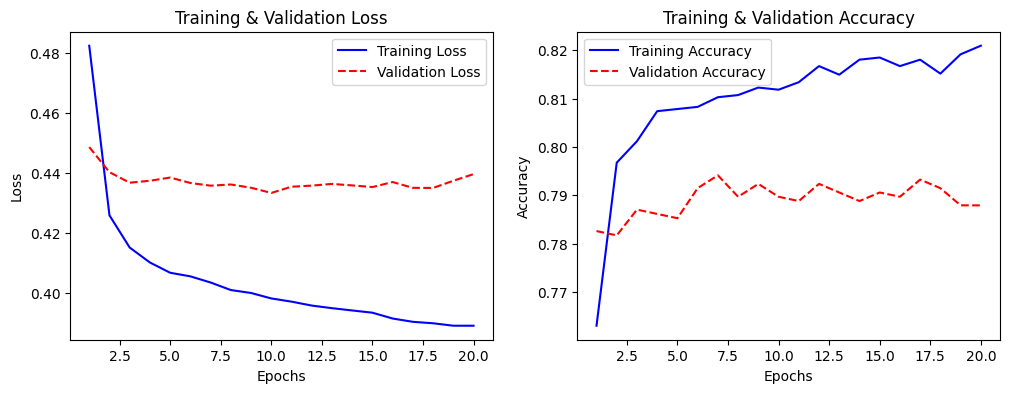

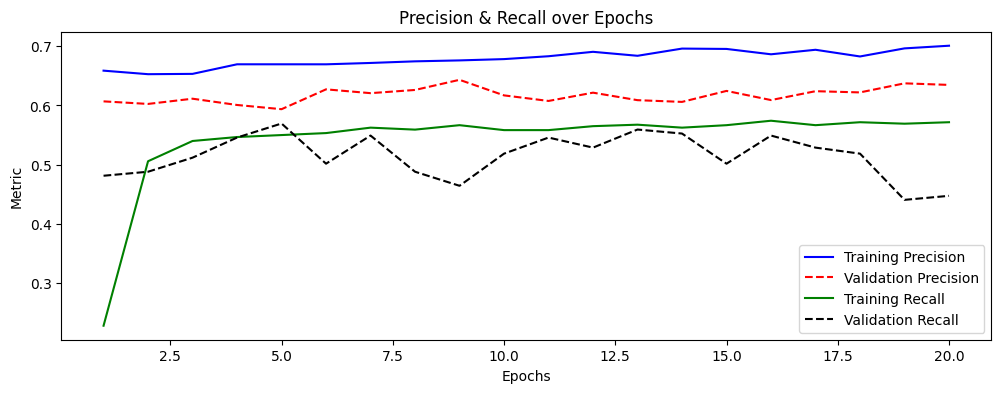

In [20]:
import matplotlib.pyplot as plt

# Extract metrics from history
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
precision = history.history['precision']
val_precision = history.history['val_precision']
recall = history.history['recall']
val_recall = history.history['val_recall']

epochs = range(1, len(loss)+1)

# Plot Loss
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs, loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'r--', label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, accuracy, 'b-', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'r--', label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Optional: Plot Precision and Recall
plt.figure(figsize=(12,4))
plt.plot(epochs, precision, 'b-', label='Training Precision')
plt.plot(epochs, val_precision, 'r--', label='Validation Precision')
plt.plot(epochs, recall, 'g-', label='Training Recall')
plt.plot(epochs, val_recall, 'k--', label='Validation Recall')
plt.title('Precision & Recall over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Metric')
plt.legend()
plt.show()

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
4

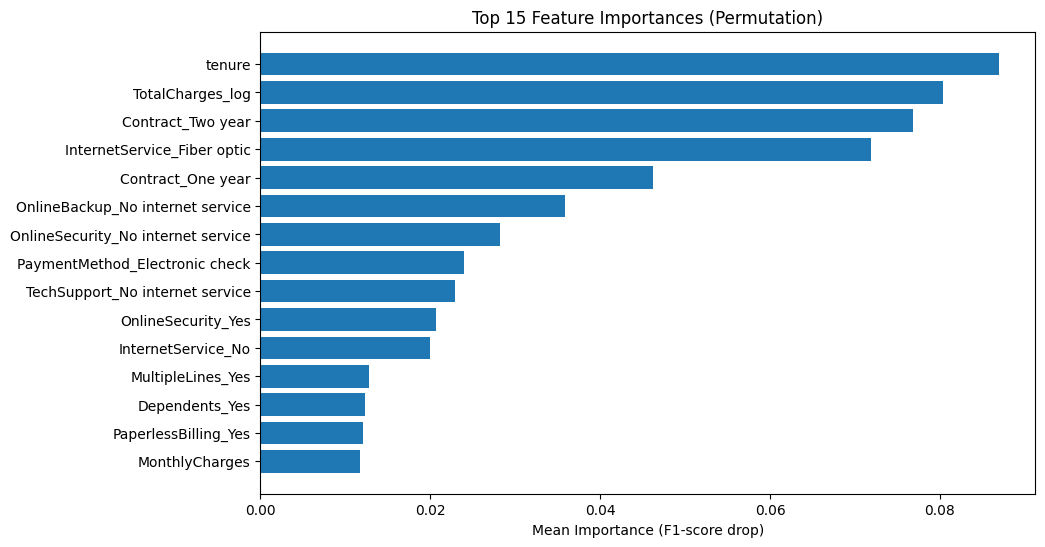

In [22]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np

# Wrap Keras model in a sklearn-like estimator
class KerasWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model):
        self.model = model

    def fit(self, X, y):
        return self  # Already trained

    def predict(self, X):
        # Convert probabilities to 0/1 labels
        y_pred_prob = self.model.predict(X)
        return (y_pred_prob > 0.5).astype(int).ravel()

# Create wrapper instance
wrapped_model = KerasWrapper(baseline_model)

# Compute permutation importance
perm_importance = permutation_importance(
    wrapped_model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1'
)

# Feature names
feature_names = X_test.columns

# Sort features by importance
sorted_idx = perm_importance.importances_mean.argsort()[::-1]

# Plot top 15 features
plt.figure(figsize=(10,6))
plt.barh(range(15), perm_importance.importances_mean[sorted_idx][:15])
plt.yticks(range(15), feature_names[sorted_idx][:15])
plt.xlabel("Mean Importance (F1-score drop)")
plt.title("Top 15 Feature Importances (Permutation)")
plt.gca().invert_yaxis()
plt.show()

In [26]:
import pandas as pd

# Create a DataFrame of features and their importance
feature_importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': perm_importance.importances_mean
})

# Sort by importance descending
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

# Show top 10 features
top_features = feature_importance_df.head(50)
print(top_features)

                                  feature  importance
0                                  tenure    0.086903
2                        TotalCharges_log    0.080389
25                      Contract_Two year    0.076860
10            InternetService_Fiber optic    0.071861
24                      Contract_One year    0.046226
14       OnlineBackup_No internet service    0.035885
12     OnlineSecurity_No internet service    0.028160
28         PaymentMethod_Electronic check    0.023927
18        TechSupport_No internet service    0.022942
13                     OnlineSecurity_Yes    0.020665
11                     InternetService_No    0.020002
9                       MultipleLines_Yes    0.012779
6                          Dependents_Yes    0.012268
26                   PaperlessBilling_Yes    0.012085
1                          MonthlyCharges    0.011730
20        StreamingTV_No internet service    0.009449
15                       OnlineBackup_Yes    0.002907
27  PaymentMethod_Credit car

**Baseline Neural Network Model – Summary**

Model Architecture

    Input Layer: Size = number of features (X_train.shape[1])

    Hidden Layers:

      Dense(32, activation='relu')

      Dense(16, activation='relu')

      Output Layer: Dense(1, activation='sigmoid')

Training Configuration (Hyperparameters)

    Optimizer: adam (default learning rate = 0.001)

    Loss function: binary_crossentropy

    Metrics: accuracy, Precision, Recall, AUC

    Epochs: 20

    Batch size: 32

    Validation split: 20% of training data

Learned Parameters

    Weights and biases for all layers (learned during training)

Performance on Test Set

    Accuracy: 79.4%

    Precision: 64.1%

    Recall: 51.1%

    F1-score: 0.568

    AUC: 0.841

Observations


*   Accuracy is reasonably high, but recall is low.
*   Class imbalance (1:3) is likely causing the model to favor the majority class.
*   F1-score indicates the balance between precision and recall can be improved.

Next Steps

*   Address class imbalance using class weights or resampling.
*   Adjust the classification threshold to improve recall and F1-score.
*   Optionally tune hyperparameters (epochs, batch size, learning rate, dropout) after addressing imbalance.










